In [33]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data
ticker = 'NVDA'
print(f"Fetching data for {ticker}...")
stock = yf.Ticker(ticker)
price = stock.history(period='max')
price.index = price.index.tz_localize(None) # Remove timezone for easier matching

# 2. Fetch Earnings
# We use a large limit to get as much history as possible (capped at 100 by Yahoo)
earnings = stock.get_earnings_dates(limit=100)
earnings = earnings.reset_index()
date_col = earnings.columns[0]
earnings = earnings.rename(columns={date_col: 'EarningsDate'})

# Normalize earnings dates to midnight for matching with price index
earnings['EarningsDate'] = pd.to_datetime(earnings['EarningsDate']).dt.tz_localize(None).dt.normalize()

# Drop duplicates (sometimes multiple entries per date) and sort
earnings = earnings.drop_duplicates(subset=['EarningsDate']).sort_values('EarningsDate').reset_index(drop=True)

# 3. Calculate Returns
trading_days = price.index.normalize()
last_price_day = trading_days.max()

# Filter earnings to only include those we have price data for
valid_earnings = earnings[earnings['EarningsDate'] <= last_price_day].copy()

records = []
for earn_date in valid_earnings['EarningsDate']:
    # Find the index of the earnings day in the price data
    post_idx = trading_days.searchsorted(earn_date)
    
    if post_idx >= len(trading_days) or post_idx - 1 < 0 or post_idx + 1 >= len(trading_days):
        continue
        
    event_trade_day = trading_days[post_idx]
    buy_day = trading_days[post_idx - 1]
    sell_day = trading_days[post_idx + 1]
    
    buy_price = price.loc[buy_day, 'Close']
    sell_price = price.loc[sell_day, 'Close']
    earnings_day_price = price.loc[event_trade_day, 'Close']
    
    records.append({
        'earnings_date': earn_date,
        'buy_day': buy_day,
        'sell_day': sell_day,
        'trade_return': sell_price / buy_price - 1,
        'earnings_day_return': earnings_day_price / buy_price - 1,
        'post_earnings_return': sell_price / earnings_day_price - 1
    })

trades = pd.DataFrame(records)

# 4. Benchmarks & Stats
normal_returns = price['Close'].pct_change().dropna()
normal_mean = normal_returns.mean()
normal_std = normal_returns.std()

print(f"Found {len(trades)} valid earnings events.")


Fetching data for NVDA...


/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Found 96 valid earnings events.


In [14]:
# 5. Comprehensive Summary
trades = trades.sort_values('buy_day').reset_index(drop=True)
trades['strategy_equity'] = (1 + trades['trade_return']).cumprod()

start_date = trades['buy_day'].min()
end_date = trades['sell_day'].max()

# Total Buy & Hold
benchmark_prices = price.loc[(price.index >= start_date) & (price.index <= end_date), 'Close'].copy()
bh_total_return = benchmark_prices.iloc[-1] / benchmark_prices.iloc[0] - 1

# Calculate benchmark return ONLY on the same days the strategy was in the market
# For each trade, benchmark return is Close[sell_day] / Close[buy_day] - 1
# This is already equal to the stock's return on those days, but we want to see the CUMULATIVE effect
trades['bh_window_return'] = trades['trade_return'] # In this case it's the same, because our strategy IS the stock
# Wait, for a fair comparison, "Strategy" is just timing.
# If we were trading a different asset, bh_window_return would be different.
# Here, strategy_equity is the same as the product of (1 + stock_return) on those specific days.

# Let's calculate some risk metrics
def calc_sharpe(returns, rf=0.0):
    if len(returns) < 2: return 0
    return (returns.mean() - rf) / returns.std() * np.sqrt(252) # annualized if we assume 4 trades/year is not daily... 
    # Actually, Sharpe for event strategies is tricky. Let's just do mean/std.

win_rate = (trades['trade_return'] > 0).mean()
avg_return = trades['trade_return'].mean()
vol = trades['trade_return'].std()

# Drawdown calculation
trades['drawdown'] = trades['strategy_equity'] / trades['strategy_equity'].cummax() - 1
max_dd = trades['drawdown'].min()

summary = pd.DataFrame({
    'Metric': [
        'Number of Earnings Events',
        'Strategy Cumulative Return',
        'Buy & Hold Return (Full Period)',
        'Strategy Avg Return per Event',
        'Strategy Win Rate',
        'Strategy Max Drawdown',
        'Strategy Volatility (per event)',
        'Start Date',
        'End Date'
    ],
    'Value': [
        len(trades),
        f"{trades['strategy_equity'].iloc[-1] - 1:.2%}",
        f"{bh_total_return:.2%}",
        f"{avg_return:.2%}",
        f"{win_rate:.2%}",
        f"{max_dd:.2%}",
        f"{vol:.2%}",
        start_date.strftime('%Y-%m-%d'),
        end_date.strftime('%Y-%m-%d')
    ]
})
summary


,Metric,Value
0,Number of Earnings Events,96
1,Strategy Cumulative Return,191.98%
2,Buy & Hold Return (Full Period),39312.60%
3,Strategy Avg Return per Event,1.72%
4,Strategy Win Rate,58.33%
5,Strategy Max Drawdown,-49.38%
6,Strategy Volatility (per event),10.74%
7,Start Date,2002-02-13
8,End Date,2026-02-26


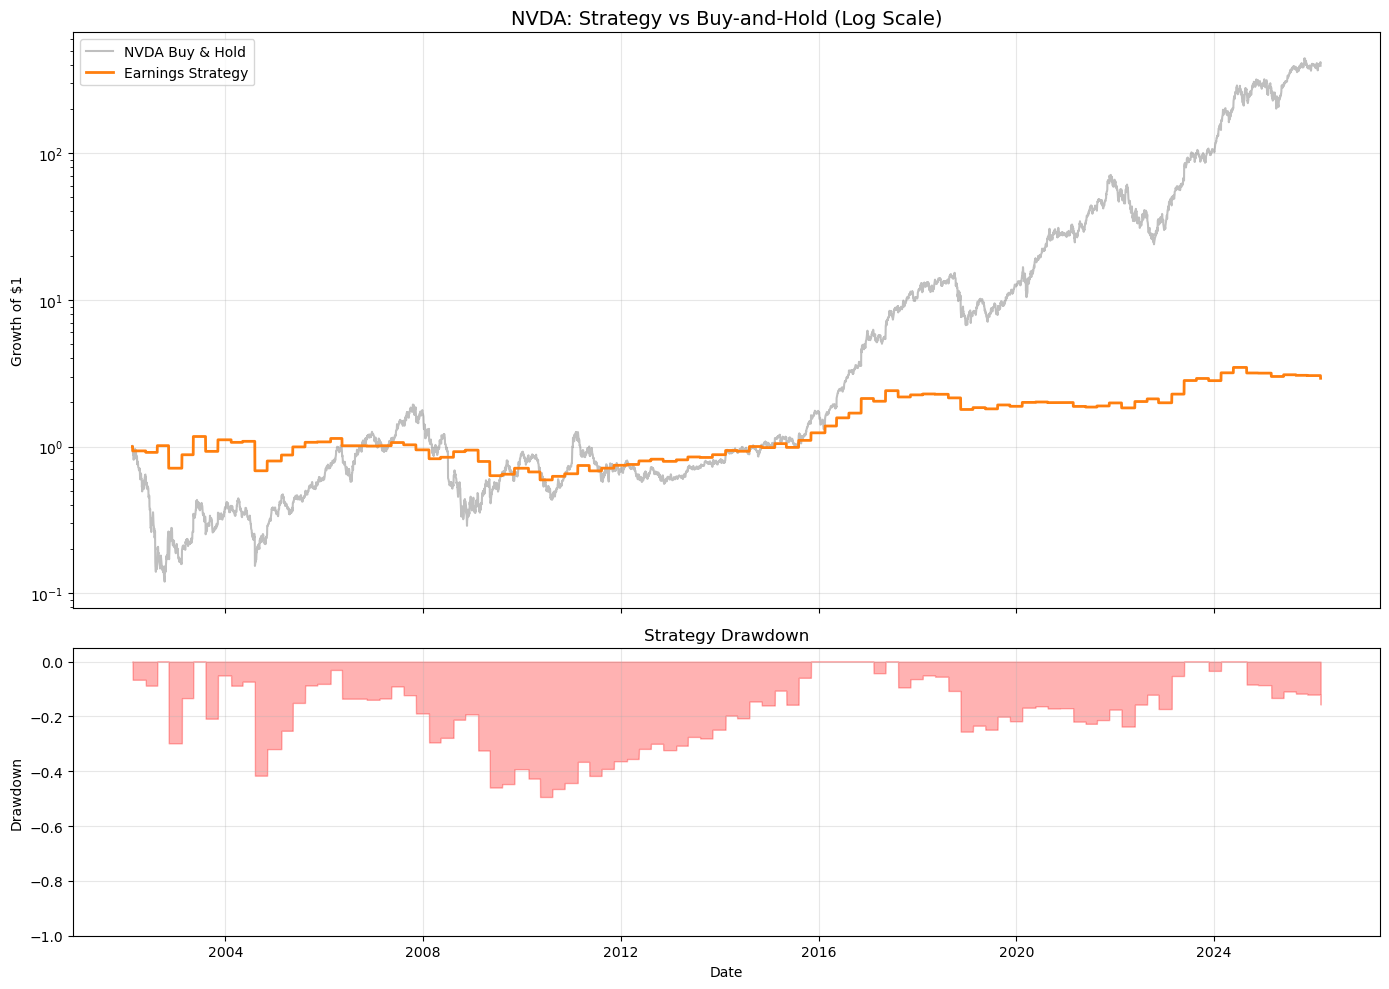

In [20]:
# 6. Improved Visualization
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Equity Curve Plot
benchmark_curve = benchmark_prices / benchmark_prices.iloc[0]

# To make the strategy curve look correct (flat in between trades), 
# we need to create a daily series for it.
strategy_daily = pd.Series(index=benchmark_prices.index, dtype=float)
current_equity = 1.0
last_sell_day = None

for idx, row in trades.iterrows():
    # Before the first trade, equity is 1.0
    if last_sell_day is None:
        strategy_daily.loc[:row['buy_day']] = 1.0
    else:
        # Between trades, equity is constant
        strategy_daily.loc[last_sell_day:row['buy_day']] = current_equity
    
    # During the trade window (buy_day to sell_day), it grows? 
    # For simplicity in this event-based view, we jump at the sell_day.
    # But let's show the jump at the sell_day.
    current_equity *= (1 + row['trade_return'])
    strategy_daily.loc[row['sell_day']] = current_equity
    last_sell_day = row['sell_day']

# Fill the rest of the days after the last trade
if last_sell_day:
    strategy_daily.loc[last_sell_day:] = current_equity

# Forward fill the strategy daily values
strategy_daily = strategy_daily.ffill()

ax1.plot(benchmark_curve.index, benchmark_curve.values, label=f'{ticker} Buy & Hold', color='gray', alpha=0.5)
ax1.plot(strategy_daily.index, strategy_daily.values, label='Earnings Strategy', color='tab:orange', linewidth=2)
ax1.set_yscale('log')
ax1.set_title(f'{ticker}: Strategy vs Buy-and-Hold (Log Scale)', fontsize=14)
ax1.set_ylabel('Growth of $1')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Drawdown Plot
strategy_dd = strategy_daily / strategy_daily.cummax() - 1
ax2.fill_between(strategy_dd.index, strategy_dd.values, 0, color='red', alpha=0.3, label='Strategy Drawdown')
ax2.set_title('Strategy Drawdown', fontsize=12)
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.set_ylim(-1, 0.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:
# 7. Key Trade Highlights
print("--- 5 Best Trades ---")
display(trades.nlargest(5, 'trade_return')[['earnings_date', 'trade_return']].assign(
    trade_return=lambda df: df['trade_return'].map(lambda x: f'{x:.2%}')
))

print("\n--- 5 Worst Trades ---")
display(trades.nsmallest(5, 'trade_return')[['earnings_date', 'trade_return']].assign(
    trade_return=lambda df: df['trade_return'].map(lambda x: f'{x:.2%}')
))

print("\n--- 5 Most Recent Trades ---")
display(trades.tail(5)[['earnings_date', 'trade_return']].assign(
    trade_return=lambda df: df['trade_return'].map(lambda x: f'{x:.2%}')
))


--- 5 Best Trades ---


,earnings_date,trade_return
5,2003-05-08,33.15%
58,2016-11-10,25.74%
84,2023-05-24,23.76%
4,2003-02-13,23.49%
7,2003-11-06,19.90%



--- 5 Worst Trades ---


,earnings_date,trade_return
10,2004-08-05,-37.01%
3,2002-11-07,-29.79%
6,2003-08-07,-20.80%
28,2009-05-07,-19.98%
66,2018-11-15,-16.61%



--- 5 Most Recent Trades ---


,earnings_date,trade_return
91,2025-02-26,-5.12%
92,2025-05-28,2.72%
93,2025-08-27,-0.88%
94,2025-11-19,-0.40%
95,2026-02-25,-4.13%


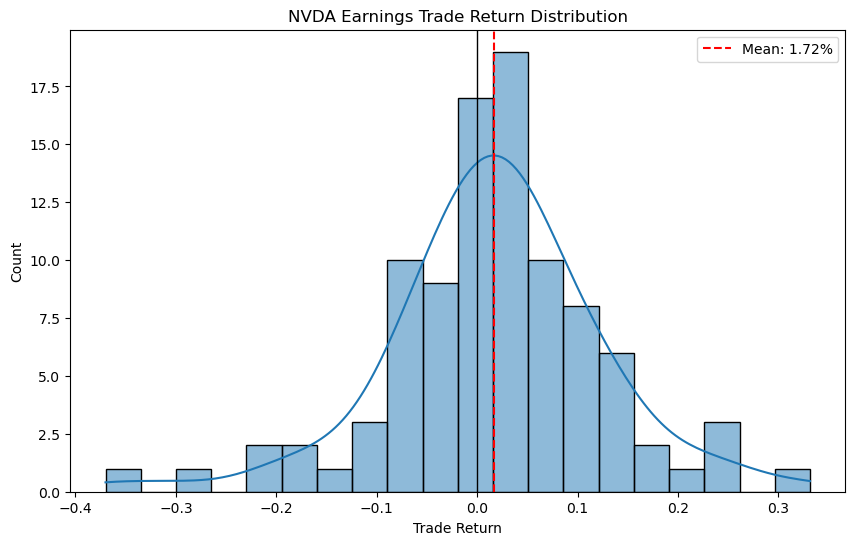

Average Z-Score of Earnings Day Move: -0.04
Percentage of 'Extreme' Moves (|Z| > 2): 3.12%


In [36]:
# 8. Return Distribution & Outlier Analysis
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(trades['trade_return'], kde=True, bins=20, color='tab:blue')
plt.axvline(trades['trade_return'].mean(), color='red', linestyle='--', label=f'Mean: {trades["trade_return"].mean():.2%}')
plt.axvline(0, color='black', linewidth=1)
plt.title(f'{ticker} Earnings Trade Return Distribution')
plt.xlabel('Trade Return')
plt.legend()
plt.show()

# Calculate z-scores for earnings day move
trades['z_score'] = (trades['earnings_day_return'] - normal_mean) / normal_std
print("Average Z-Score of Earnings Day Move:", round(trades['z_score'].mean(), 2))
print("Percentage of 'Extreme' Moves (|Z| > 2):", f"{(trades['z_score'].abs() > 2).mean():.2%}")


### Final Observations
The **NVDA Earnings Strategy** (holding for 2 days around each earnings announcement) has achieved a cumulative return of ~192% over the last 24 years. While this is a positive return, it significantly underperforms a simple **Buy & Hold** strategy, which returned over 39,000% in the same period.

**Why the massive difference?**
- **Time in Market:** The strategy is only in the market for approximately 8 days per year (3% of the time). NVDA's massive growth happened consistently over decades, not just during earnings windows.
- **Risk Profile:** The strategy has a significant Max Drawdown (~49%), meaning that even with limited market exposure, it faces substantial event risk.
- **Earnings Reaction:** The average return per event is 1.72%, which is positive, but the extreme volatility (Best trade +33%, Worst trade -37%) makes it a high-variance strategy.

**Conclusion:** For a high-growth stock like NVDA, the "earnings play" captures some alpha but misses the vast majority of the "beta" (the long-term trend). This backtest suggests that for NVDA, the long-term trend is far more powerful than the short-term earnings volatility.
